# OilyGiant · Selección de región para 200 nuevos pozos

**Objetivo de negocio:** decidir en cuál de tres regiones desarrollar 200 pozos petroleros nuevos, maximizando el beneficio total y manteniendo el riesgo de pérdida por debajo del 2.5%.

**Método:** regresión lineal para predecir el volumen de reservas por pozo, selección de los mejores pozos, y análisis de beneficio y riesgo con *bootstrapping* (intervalo de confianza al 95% y probabilidad de pérdida).

## Resumen ejecutivo

**Recomendación: desarrollar los 200 pozos en la Región 1.** Es la única de las tres que mantiene el riesgo de pérdida por debajo del umbral del 2.5% y, además, ofrece el mayor beneficio esperado.

- **Región recomendada:** Región 1
- **Beneficio promedio esperado:** $4,560,451 USD
- **Riesgo de pérdida:** 1.5% (cumple el umbral < 2.5%)
- **Intervalo de confianza 95%:** [$338,205, $8,522,895] — el límite inferior es positivo: incluso en el peor escenario razonable, la inversión gana.

_En una línea:_ con un presupuesto de $100M, la Región 1 es la única decisión segura — máximo beneficio esperado con el menor riesgo, y un piso de ganancia que nunca toca pérdida.

## Contexto de negocio, condiciones y supuestos

### El problema
OilyGiant invertirá en 200 pozos nuevos en **una** de tres regiones. La pregunta de negocio no es "¿qué modelo predice mejor?", sino **"¿dónde se coloca el capital para maximizar el beneficio sin exponerse a una pérdida probable?"**.

### Condiciones del negocio
| Parámetro | Valor |
|---|---|
| Presupuesto total | 100,000,000 USD |
| Pozos a desarrollar | 200 |
| Puntos estudiados por región | 500 (se eligen los 200 mejores) |
| Ingreso por unidad de producto (mil barriles) | 4,500 USD |
| Ingreso por barril | 4.5 USD |
| Umbral de riesgo de pérdida | < 2.5 % |
| Modelo permitido | Solo regresión lineal |

### Supuestos
- `product` está en **miles de barriles**; el ingreso es lineal con el volumen.
- El presupuesto cubre el desarrollo de los 200 pozos; no se modelan costos operativos adicionales.
- La selección real (200 de 500) se simula con *bootstrapping* sobre el conjunto de validación, según la condición del proyecto.
- Las tres regiones se asumen comparables en costo; la decisión depende solo de beneficio y riesgo.

### Criterio de decisión
1. Descartar regiones con riesgo de pérdida ≥ 2.5 %.
2. Entre las que pasan, elegir la de **mayor beneficio promedio**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 12345

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Paso 1 · Carga y preparación de los datos

Cargamos las tres regiones desde `data/raw/` en DataFrames separados y los agrupamos en un diccionario `regions`, para poder recorrerlos con el mismo código y no duplicar lógica.

Enseguida verificamos la **calidad de los datos** antes de modelar: tipos de columna, valores nulos, duplicados (incluido `id` repetido) y un primer vistazo a la distribución de `product` y a la relación de `f0`, `f1`, `f2` con el objetivo. Esto confirma si hace falta limpiar algo y nos da los primeros hallazgos por región.

In [2]:
geo_0 = pd.read_csv("data/raw/geo_data_0.csv")
geo_1 = pd.read_csv("data/raw/geo_data_1.csv")
geo_2 = pd.read_csv("data/raw/geo_data_2.csv")

regions = {"Región 0": geo_0, "Región 1": geo_1, "Región 2": geo_2}

geo_0.head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [3]:
for name, df in regions.items():
    print(f"--- {name} ---")
    print(f"Forma: {df.shape}")
    print(f"Nulos por columna:\n{df.isna().sum()}")
    print(f"Filas duplicadas: {df.duplicated().sum()}")
    print(f"IDs duplicados: {df['id'].duplicated().sum()}")
    print()

--- Región 0 ---
Forma: (100000, 5)
Nulos por columna:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Filas duplicadas: 0
IDs duplicados: 10

--- Región 1 ---
Forma: (100000, 5)
Nulos por columna:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Filas duplicadas: 0
IDs duplicados: 4

--- Región 2 ---
Forma: (100000, 5)
Nulos por columna:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Filas duplicadas: 0
IDs duplicados: 4



In [4]:
for name, df in regions.items():
    print(f"--- {name} ---")
    print(df.describe())
    print()

--- Región 0 ---
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        0.500419       0.250143       2.502647      92.500000
std         0.871832       0.504433       3.248248      44.288691
min        -1.408605      -0.848218     -12.088328       0.000000
25%        -0.072580      -0.200881       0.287748      56.497507
50%         0.502360       0.250252       2.515969      91.849972
75%         1.073581       0.700646       4.715088     128.564089
max         2.362331       1.343769      16.003790     185.364347

--- Región 1 ---
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        1.141296      -4.796579       2.494541      68.825000
std         8.965932       5.119872       1.703572      45.944423
min       -31.609576     -26.358598      -0.018144       0.000000
25%        -6.298551      -8.267985      

### Hallazgos
- **Calidad:** _(pendiente: nulos / duplicados)_
- **Reservas promedio (`product`):** R0 = 92.5 · R1 = 68.8 · R2 = 95.0 (miles de barriles). Región 2 la más alta, Región 1 la más baja.
- **Región 1 atípica:** features en escalas distintas y `product` estructurado (mediana 57 « media 68.8, techo más bajo). Se anticipa mayor precisión del modelo en R1.
- **Equilibrio:** el umbral de rentabilidad es 111.1 unidades/pozo; las tres medias están por debajo → ninguna región es rentable "en promedio", la ganancia vendrá de seleccionar los mejores pozos.

## Paso 2 · Entrenamiento y evaluación del modelo por región

Para cada región separamos las features (`f0`, `f1`, `f2`) del objetivo (`product`), dividimos 75/25 en entrenamiento y validación, entrenamos una regresión lineal y predecimos sobre validación. Guardamos predicciones y valores reales (los necesitaremos en el cálculo de ganancia y el bootstrapping) y reportamos el volumen medio predicho y el RMSE.

Toda la lógica vive en una sola función reutilizable que aplicamos a las tres regiones — sin duplicar código.

In [5]:
def train_evaluate_region(df, random_state=RANDOM_STATE):
    features = df.drop(columns=["id", "product"])
    target = df["product"]

    features_train, features_valid, target_train, target_valid = train_test_split(
        features, target, test_size=0.25, random_state=random_state
    )

    model = LinearRegression()
    model.fit(features_train, target_train)
    predictions = pd.Series(model.predict(features_valid), index=target_valid.index)

    rmse = mean_squared_error(target_valid, predictions) ** 0.5

    return predictions, target_valid, predictions.mean(), rmse

In [6]:
results = {}
for name, df in regions.items():
    preds, target_valid, mean_pred, rmse = train_evaluate_region(df)
    results[name] = {"pred": preds, "target": target_valid, "mean_pred": mean_pred, "rmse": rmse}
    print(f"{name}: volumen medio predicho = {mean_pred:.2f} | RMSE = {rmse:.2f}")

Región 0: volumen medio predicho = 92.59 | RMSE = 37.58
Región 1: volumen medio predicho = 68.73 | RMSE = 0.89
Región 2: volumen medio predicho = 94.97 | RMSE = 40.03


### Hallazgos
- **Media predicha / RMSE:** R0 = 92.59 / 37.58 · R1 = 68.73 / 0.89 · R2 = 94.97 / 40.03
- **Lectura honesta:** R1 tiene un RMSE casi nulo (0.89) — el modelo la predice casi a la perfección, confirmando la hipótesis del Paso 1 (su `product` es estructurado). R0 y R2 tienen RMSE alto (37.6 y 40.0), un error cercano al 40% de su media: el modelo apenas distingue pozos buenos de malos.
- **La tensión central:** R1 es precisa pero de bajo volumen (68.7); R0 y R2 son de alto volumen pero imprecisas. Ninguna gana de forma obvia — por eso el análisis de riesgo (Paso 5) es el que decide.
- **Implicación:** un RMSE alto no invalida la estrategia. No necesitamos predecir bien cada pozo, solo distinguir los mejores 200. La decisión pesará precisión, volumen y riesgo juntos.

## Paso 3 · Preparación del cálculo de ganancia (punto de equilibrio)

Guardamos las condiciones del negocio en variables y calculamos el **volumen de equilibrio**: cuántas reservas debe producir un pozo para no perder dinero. Lo comparamos contra la media de cada región para entender el punto de partida antes de seleccionar pozos.

In [7]:
BUDGET = 100_000_000
N_WELLS = 200
N_STUDIED = 500
REVENUE_PER_UNIT = 4500

break_even_volume = BUDGET / N_WELLS / REVENUE_PER_UNIT
print(f"Volumen de equilibrio por pozo: {break_even_volume:.1f} mil barriles")

Volumen de equilibrio por pozo: 111.1 mil barriles


In [8]:
for name, df in regions.items():
    mean_reserve = df["product"].mean()
    gap = mean_reserve - break_even_volume
    print(f"{name}: media {mean_reserve:.2f} | equilibrio {break_even_volume:.1f} | diferencia {gap:+.2f}")

Región 0: media 92.50 | equilibrio 111.1 | diferencia -18.61
Región 1: media 68.83 | equilibrio 111.1 | diferencia -42.29
Región 2: media 95.00 | equilibrio 111.1 | diferencia -16.11


### Conclusiones
- **Volumen de equilibrio:** 111.1 mil barriles por pozo.
- **Medias reales:** R0 = 92.50 · R1 = 68.83 · R2 = 95.00 — las tres **por debajo** del equilibrio (diferencias de −18.6, −42.3 y −16.1).
- **Lectura:** ninguna región es rentable "en promedio". La ganancia no viene de perforar al azar, sino de **seleccionar los mejores 200 de 500 pozos**.
- **Matiz por región:** R0 y R2 arrancan más cerca del equilibrio; R1 es la más lejana en promedio, pero su predicción casi perfecta (RMSE 0.89) le permite seleccionar con mucha confianza los mejores pozos — una ventaja que el promedio no muestra.
- **Cómo se calculará el beneficio:** con las predicciones se eligen los 200 pozos de mayor valor predicho por región, se suma su volumen **real**, y la ganancia es (volumen × 4500) − presupuesto.

## Paso 4 · Función de ganancia y selección de pozos

La estrategia: se eligen los 200 pozos con mayor valor **predicho**, pero la ganancia se calcula con su volumen **real**. Es la lógica del negocio: decides dónde perforar con el modelo, pero cobras lo que el pozo realmente produce.

Ganancia = (volumen real de los 200 seleccionados × 4500) − presupuesto.

In [9]:
def profit(target, predictions, n_wells=N_WELLS):
    top_indices = predictions.sort_values(ascending=False).index[:n_wells]
    selected_volume = target.loc[top_indices].sum()
    return selected_volume * REVENUE_PER_UNIT - BUDGET

In [10]:
for name in results:
    p = profit(results[name]["target"], results[name]["pred"])
    print(f"{name}: ganancia potencial = ${p:,.0f}")

Región 0: ganancia potencial = $33,208,260
Región 1: ganancia potencial = $24,150,867
Región 2: ganancia potencial = $27,103,500


### Conclusiones
- **Ganancia potencial (top 200):** R0 = $33,208,260 · R1 = $24,150,867 · R2 = $27,103,500
- **Recomendación provisional (4.3):** la **Región 0**, con la mayor ganancia puntual ($33.2 M). Seleccionando bien, las tres superan el presupuesto.
- **Advertencia:** es una sola pasada sobre todo el conjunto de validación, sin medir variabilidad. La más rentable aquí podría no ser la de menor riesgo. El Paso 5 lo confirma o lo cambia.

## Paso 5 · Riesgo y beneficio con bootstrapping

Una sola pasada no mide incertidumbre. Con *bootstrapping* simulamos repetir el estudio 1000 veces: en cada repetición tomamos 500 pozos al azar (con reemplazo), elegimos los 200 de mayor predicción y calculamos la ganancia. Eso construye una **distribución** de beneficios por región, de la que sacamos el beneficio promedio, el intervalo de confianza al 95% y el riesgo de pérdida.

El límite inferior del intervalo (percentil 2.5) es, en lenguaje financiero, el **Value at Risk**: el peor escenario con 97.5% de confianza.

In [11]:
def bootstrap_profit(target, predictions, n_samples=1000, n_studied=N_STUDIED, n_wells=N_WELLS):
    state = np.random.RandomState(RANDOM_STATE)
    target = target.reset_index(drop=True)
    predictions = predictions.reset_index(drop=True)
    profits = []
    for _ in range(n_samples):
        positions = state.choice(len(target), size=n_studied, replace=True)
        sample_target = target.iloc[positions].reset_index(drop=True)
        sample_pred = predictions.iloc[positions].reset_index(drop=True)
        profits.append(profit(sample_target, sample_pred, n_wells))
    return pd.Series(profits)

In [12]:
for name in results:
    dist = bootstrap_profit(results[name]["target"], results[name]["pred"])
    mean_profit = dist.mean()
    lower = dist.quantile(0.025)
    upper = dist.quantile(0.975)
    risk = (dist < 0).mean() * 100
    print(f"{name}: promedio ${mean_profit:,.0f} | IC95% [${lower:,.0f}, ${upper:,.0f}] | riesgo {risk:.1f}%")

Región 0: promedio $3,961,650 | IC95% [$-1,112,155, $9,097,669] | riesgo 6.9%
Región 1: promedio $4,560,451 | IC95% [$338,205, $8,522,895] | riesgo 1.5%
Región 2: promedio $4,044,039 | IC95% [$-1,633,504, $9,503,596] | riesgo 7.6%


In [13]:
distributions = {name: bootstrap_profit(results[name]["target"], results[name]["pred"]) for name in results}

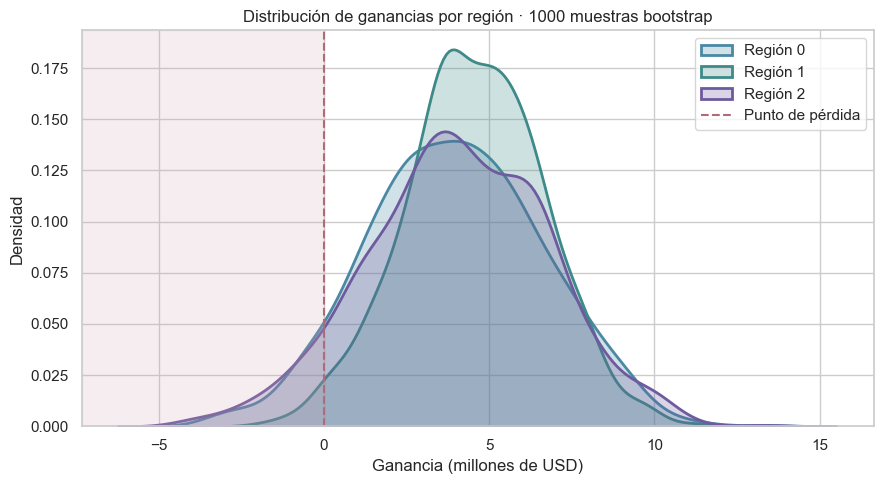

In [15]:
region_colors = {"Región 0": "#4A88A4", "Región 1": "#3D8A88", "Región 2": "#6E5A9E"}

fig, ax = plt.subplots(figsize=(9, 5))
for name, dist in distributions.items():
    sns.kdeplot(dist / 1e6, ax=ax, color=region_colors[name], fill=True, alpha=0.25, linewidth=2, label=name)
xmin = ax.get_xlim()[0]
ax.axvspan(xmin, 0, color="#D4A8B4", alpha=0.20)
ax.axvline(0, color="#B06B78", linewidth=1.5, linestyle="--", label="Punto de pérdida")
ax.set_xlim(left=xmin)
ax.set_xlabel("Ganancia (millones de USD)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de ganancias por región · 1000 muestras bootstrap")
ax.legend()
plt.tight_layout()
plt.savefig("reports/figures/distribucion_ganancias.png", dpi=150)
plt.show()

### Conclusiones · recomendación final
- **Promedio / IC 95% / riesgo de pérdida:**
  - R0: $3,961,650 · [−$1,112,155, $9,097,669] · 6.9%
  - R1: $4,560,451 · [$338,205, $8,522,895] · 1.5%
  - R2: $4,044,039 · [−$1,633,504, $9,503,596] · 7.6%
- **Filtro de riesgo (< 2.5%):** solo **R1** lo cumple; R0 y R2 rondan el 7%, fuera de norma.
- **Recomendación final: Región 1.** Única bajo el umbral de riesgo y, además, la de mayor beneficio promedio. Su modelo casi perfecto (RMSE 0.89) hace confiable la selección de pozos, lo que produce una distribución estrecha con piso positivo (+$338K): gana incluso en los peores escenarios.
- **¿Coincide con el Paso 4.3?** No. El 4.3 señaló R0 por su mayor ganancia en una sola pasada ($33.2M), pero el bootstrapping revela que esa ganancia es inestable: R0 pierde en el 6.9% de los escenarios. El muestreo repetido expone la varianza que un solo cálculo esconde. La decisión segura es **R1**.

## Sensibilidad · ¿la recomendación aguanta si cambia el precio del crudo?

Un inversionista preguntará: "¿y si el precio del petróleo baja?". Como la selección de pozos no depende del precio, reescalamos las distribuciones de ganancia ya calculadas: a un factor `f` del precio base, cada ganancia pasa a `(ganancia + presupuesto) × f − presupuesto`. Con eso recalculamos el riesgo de cada región a distintos niveles de precio.

In [16]:
factors = [0.90, 0.95, 0.98, 1.00, 1.05, 1.10]
print(f"{'Precio':>7} | {'R0':>7} | {'R1':>7} | {'R2':>7}")
for f in factors:
    risks = {name: ((dist + BUDGET) * f - BUDGET < 0).mean() * 100 for name, dist in distributions.items()}
    print(f"{f*100:>6.0f}% | {risks['Región 0']:>6.1f}% | {risks['Región 1']:>6.1f}% | {risks['Región 2']:>6.1f}%")

 Precio |      R0 |      R1 |      R2
    90% |   99.8% |   99.9% |   99.8%
    95% |   68.8% |   62.6% |   66.1%
    98% |   24.2% |   11.4% |   22.9%
   100% |    6.9% |    1.5% |    7.6%
   105% |    0.0% |    0.0% |    0.0%
   110% |    0.0% |    0.0% |    0.0%


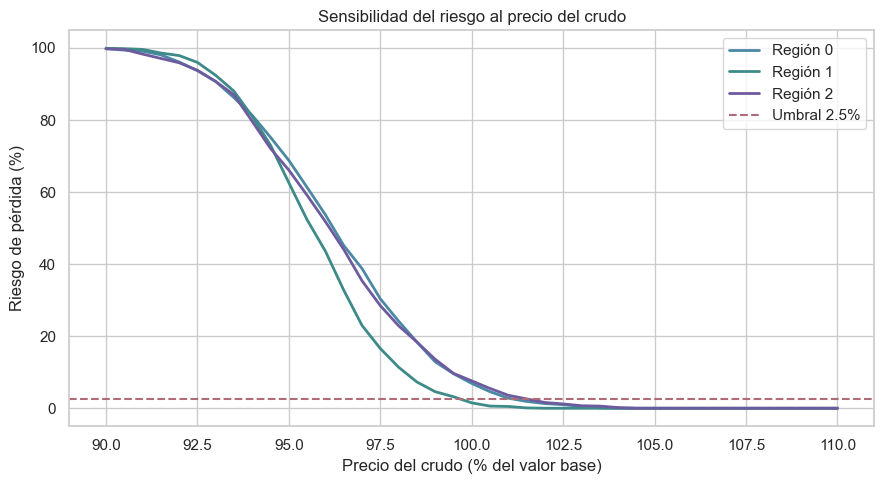

In [17]:
factors = np.linspace(0.90, 1.10, 41)
fig, ax = plt.subplots(figsize=(9, 5))
for name, dist in distributions.items():
    risks = [((dist + BUDGET) * f - BUDGET < 0).mean() * 100 for f in factors]
    ax.plot(factors * 100, risks, color=region_colors[name], linewidth=2, label=name)
ax.axhline(2.5, color="#B06B78", linestyle="--", linewidth=1.5, label="Umbral 2.5%")
ax.set_xlabel("Precio del crudo (% del valor base)")
ax.set_ylabel("Riesgo de pérdida (%)")
ax.set_title("Sensibilidad del riesgo al precio del crudo")
ax.legend()
plt.tight_layout()
plt.savefig("reports/figures/sensibilidad_precio.png", dpi=150)
plt.show()

In [18]:
factors = np.linspace(0.90, 1.10, 2001)
for name, dist in distributions.items():
    risks = np.array([((dist + BUDGET) * f - BUDGET < 0).mean() * 100 for f in factors])
    qualifies = factors[risks <= 2.5]
    cross = qualifies.min() * 100 if len(qualifies) else None
    print(f"{name}: cumple < 2.5% a partir de {cross:.1f}% del precio base")

Región 0: cumple < 2.5% a partir de 101.1% del precio base
Región 1: cumple < 2.5% a partir de 99.7% del precio base
Región 2: cumple < 2.5% a partir de 101.7% del precio base


### Conclusiones de sensibilidad
- A precio base, solo R1 (1.5%) está bajo el 2.5%; R0 (6.9%) y R2 (7.6%) ya quedan fuera.
- R1 mantiene el riesgo bajo el umbral mientras el precio no caiga más de ~_(lee del gráfico)_%; por debajo de eso, ninguna región cumple.
- **Lectura honesta:** R1 es la mejor decisión, pero con margen **estrecho** ante caídas de precio. Vale señalarlo: la elección es correcta hoy, pero sensible al mercado.